 For my portion of the analysis, I chose to explore the relationship between crude oil prices and U.S. gasoline prices from 2023–2026. Specifically, I wanted to determine whether fluctuations in crude oil prices showed a measurable correlation with the prices Americans experience at the gas pump, and whether those changes appeared to move alongside broader inflation trends. 

First, I imported the libraries we will use for analysis and opened the csv files needed for analysis. They currently show the uncleaned data. 

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [33]:
gas = pd.read_csv("../data/raw/gas_prices.csv")
oil = pd.read_csv("../data/raw/crude_oil.csv")
national = pd.read_csv("../data/raw/national_prices.csv")
inflation = pd.read_csv("../data/raw/inflation.csv") 


In [34]:
print(gas.columns)
print(inflation.columns)

Index(['period', 'duoarea', 'area-name', 'product', 'product-name', 'process',
       'process-name', 'series', 'series-description', 'value', 'units'],
      dtype='str')
Index(['realtime_start', 'realtime_end', 'date', 'value'], dtype='str')


In [35]:
# In our cleaned Python file, the values were originally sorted in descending order,
# but I needed specific values displayed differently for my analysis.
# Instead of modifying the shared file, I made those adjustments here.

gas_params = {

    "frequency": "weekly",

    "data[0]": "value",

    "facets[product][]": "EPMR",

    "sort[0][column]": "period",

    "sort[0][direction]": "asc",

    "length": 5000
}

In [37]:
gas_df = gas[["period", "value"]]
oil_df = oil[["period", "value"]]

#same values for "value" so I would like to rename them and make them unique

gas_df = gas.rename(columns={"value": "gas_price"})
oil_df = oil.rename(columns={"value": "oil_price"})
inflation = inflation.rename(columns={"value": "cpi"})

#Converting the strings to datetime format

gas_df["period"] = pd.to_datetime(gas_df["period"])
oil_df["period"] = pd.to_datetime(oil_df["period"])
inflation["date"] = pd.to_datetime(inflation["date"])

##Later in my code, I had an empy data frame. this happened after the step where ## 
## I printed the period to see where my dataset lied. I have to srtip the time stamps and standardize the dates ##

gas_df["week"] = gas_df["period"].dt.to_period("W")
oil_df["week"] = oil_df["period"].dt.to_period("W")

#Lastly, I wanted to convert the string values in the price fields to ints
gas_df["gas_price"] = pd.to_numeric(gas_df["gas_price"]).round(2)
oil_df["oil_price"] = pd.to_numeric(oil_df["oil_price"]).round(2)
inflation["cpi"] = pd.to_numeric(inflation["cpi"], errors="coerce")

I placed all of the parameters I wanted in my data frame and assigned it a new variable.

In [11]:
print("Gas Start Date:" , gas_df["week"].min())
print("Gas Start Date:" , gas_df["week"].max())
print("Oil Start Date:" , oil_df["week"].min())
print("Oil End Date:" , oil_df["week"].max())

#originally this included time stamps until I corrected my code above. 

Gas Start Date: 2023-01-30/2023-02-05
Gas Start Date: 2026-05-18/2026-05-24
Oil Start Date: 1985-12-30/1986-01-05
Oil End Date: 2026-05-11/2026-05-17


The crude oil dataset includes a larger date range than the gas price dataset, so for consistency, I limited the analysis to overlapping data from 2023 through the most recent available reporting period. Since the gas price report is generated weekly and reflects the previous week’s data, both datasets were aligned by weekly periods before merging,  to ensure the comparison matched across the same timeframe. 

In [40]:
# Filter both datasets to 2023 onward
gas_2023 = gas_df[gas_df["period"] >= "2023-05-18"].copy()
oil_2023 = oil_df[oil_df["period"] >= "2023-05-18"].copy()
inflation_2023 = inflation[inflation["date"] >= "2023-05-18"].copy()

# Convert dates into matching weekly periods
gas_2023["week"] = gas_2023["period"].dt.to_period("W")
oil_2023["week"] = oil_2023["period"].dt.to_period("W")

# Merge by week
merged_2023 = pd.merge(
    gas_2023,
    oil_2023,
    on="week",
    how="inner",
    suffixes=("_gas", "_oil")
)

#print(merged_2023.shape)
#print(merged_2023.columns)
#print(merged_2023[["week", "period_gas", "period_oil"]].head())
#merged_2023[["week", "period_gas", "period_oil"]].tail()

In [41]:
# Because each dataset uses different value scales, I normalized the data below
# to better visualize the relationship and overall trends

merged_2023["gas_norm"] = (
    merged_2023["gas_price"]
    / merged_2023["gas_price"].max()
)

merged_2023["oil_norm"] = (
    merged_2023["oil_price"]
    / merged_2023["oil_price"].max()
)

inflation["cpi_norm"] = (
    inflation["cpi"]
    / inflation["cpi"].max()
)



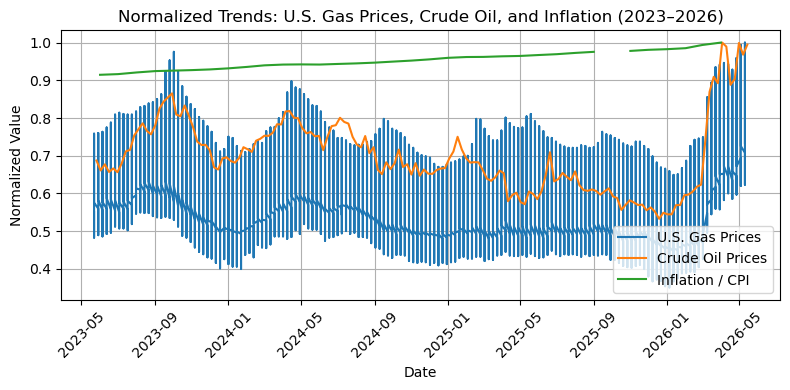

In [43]:
plt.figure(figsize=(8,4))

plt.plot(
    merged_2023["period_gas"],
    merged_2023["gas_norm"],
    label="U.S. Gas Prices"
)

plt.plot(
    merged_2023["period_oil"],
    merged_2023["oil_norm"],
    label="Crude Oil Prices"
)

plt.plot(
    inflation_2023["date"],
    inflation_2023["cpi_norm"],
    label="Inflation / CPI"
)

plt.title("Normalized Trends: U.S. Gas Prices, Crude Oil, and Inflation (2023–2026)")
plt.xlabel("Date")
plt.ylabel("Normalized Value")

plt.legend(loc = "lower right")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The graph shows that crude oil prices and U.S. gas prices generally followed similar trends between 2023 and 2026, suggesting a visible relationship between the cost of crude oil and the prices consumers pay at the gas pump. However, the fluctuation in gas prices also suggests that crude oil prices are not the only factor influencing gas prices. (as you can see more noticebaly in the scatter plot below) While inflation increased steadily over the same period, gas and oil prices experienced more noticeable fluctuations, especially leading into mid-2025.

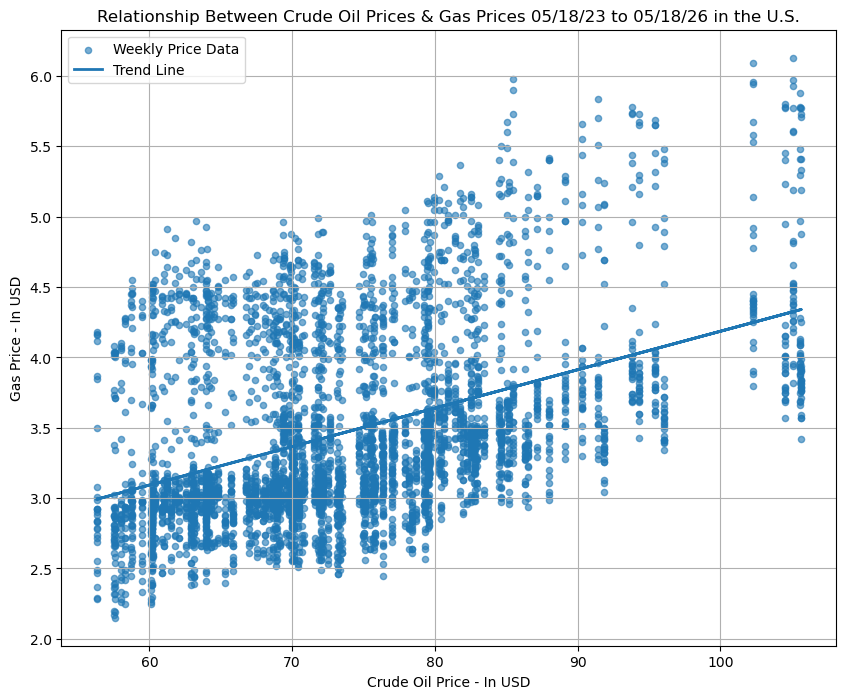

In [29]:
import numpy as np

# Keep only the columns needed for the scatterplot
plot_df = merged_2023[["oil_price", "gas_price"]].copy()

# Convert to numeric
plot_df["oil_price"] = pd.to_numeric(plot_df["oil_price"], errors="coerce")
plot_df["gas_price"] = pd.to_numeric(plot_df["gas_price"], errors="coerce")

# Remove missing/invalid values
plot_df = plot_df.dropna()

# Scatterplot
plt.figure(figsize=(10,8))

plt.scatter(
    plot_df["oil_price"],
    plot_df["gas_price"],
    alpha=0.6,
    s=20,
    label="Weekly Price Data"
)

# Trendline : I used Chat GPt for assistance with creating the trendline and resizing the visual
z = np.polyfit(
    plot_df["oil_price"],
    plot_df["gas_price"],
    1
)

p = np.poly1d(z)

plt.plot(
    plot_df["oil_price"],
    p(plot_df["oil_price"]),
    linewidth=2,
    label="Trend Line"
)

plt.xlabel("Crude Oil Price - In USD")
plt.ylabel("Gas Price - In USD")
plt.title("Relationship Between Crude Oil Prices & Gas Prices 05/18/23 to 05/18/26 in the U.S.")
plt.legend()
plt.grid(True)
plt.show()